# 05 · Continuous HMS Simulation + Event Extraction

**Author:** Salvador Navas  
**Basin:** Río Besaya — Cantabria

## Continuous vs event-based simulation — why both?

| Aspect | Event (Notebook 04) | Continuous (this notebook) |
|--------|--------------------|-----------------------------|
| Input | Single design hyetograph | Daily AMR time series (years) |
| Output | Single design hydrograph | Complete discharge time series |
| Calibration | Against design standards | Against observed streamflow |
| Soil moisture | Fixed antecedent condition | Continuously updated |
| Use | Peak discharge estimates | Calibration, event database |

**The key advantage of continuous simulation** is that it accounts for 
**antecedent soil moisture** — a wet autumn followed by a 3-day storm produces 
higher runoff than the same storm after a dry summer. The SCS-CN method 
(used in event mode) requires a fixed antecedent moisture class (AMC I/II/III).

## Continuous simulation methodology
1. Prepare the daily AMR time series by subbasin (Notebook 02)
2. Write `.gage` and `.met` files for continuous simulation (Oct 2008 – Dec 2012)
3. Run HEC-HMS in continuous mode when the external binary is available
4. Read the resulting continuous hydrograph from DSS when available
5. Compare with observed streamflow (station 1237 Torrelavega)
6. Diagnostic comparison with observed streamflow when a true HMS run is available
7. Extract above-threshold events for the downscaling step

**Execution note.** If HEC-HMS/DSS output is unavailable, the notebook loads a
precomputed proxy dataset. In that mode calibration metrics (NSE/KGE/bias) are 
not reported as calibration scores — only data availability is verified.


In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pyhydra.modeling.hydrology.hec_hms import (
    read_gages, read_basin,
    generate_gage, fill_gage,
    generate_met, generate_control, generate_run, generate_py,
    run_hms_script, read_dss6_timeseries,
)
from pyhydra.climate.time_series.events import (
    extract_discharge_events,
    extract_concurrent_events,
)

# ── Paths ──────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR   = Path(os.environ.get('HYDRA_DATA_DIR',  str(REPO_ROOT / 'data')))
TOOLS_DIR  = Path(os.environ.get('HYDRA_TOOLS_DIR', str(REPO_ROOT / 'tools')))
DATA_ROOT  = DATA_DIR / 'pilot_cases' / 'los_corrales_buelna'
PROC_DIR   = DATA_ROOT / 'processed'
HMS_DIR    = DATA_ROOT / 'models' / 'hec_hms'
OUT_DIR    = PROC_DIR / 'hms_continuous'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# HEC-HMS binary — override via HEC_HMS_BIN env var or HYDRA_TOOLS_DIR
HEC_HMS_BIN = Path(os.environ.get('HEC_HMS_BIN',
    str(TOOLS_DIR / 'hms' / 'HEC-HMS-4.13' / 'hec-hms.sh')))

NAME_MODEL  = 'Caudales_IDW'
NAME_BASIN  = 'Modelo_Besaya'
PATH_MODEL  = str(HMS_DIR / 'Caudales_IDW')

SIM_START = '1 October 2008, 00:00'
SIM_END   = '31 December 2012, 24:00'
TIME_STEP = 1440   # minutes (daily)

print(f'HMS model: {NAME_MODEL}  ({PATH_MODEL})')
print(f'Simulation period: {SIM_START} → {SIM_END}')

---
## 1. Load daily AMR by subbasin

`pma_idw_daily.csv` contains the daily areal mean rainfall (mm/day) for each 
HEC-HMS subbasin, computed in Notebook 02. Each column is a subbasin name 
matching the `.basin` file.

The simulation period is filtered to **Oct 2008 – Dec 2012** — the period with 
both observed streamflow (station 1237) and a sufficient warm-up record.

> **Why clip to Oct 2008?**  
> HMS needs ~3 months to spin up the soil moisture state. Starting in October 
> ensures the model reaches quasi-equilibrium before the winter flood season.


In [2]:
pma = pd.read_csv(PROC_DIR / 'pma_idw_daily.csv', index_col=0, parse_dates=True)
pma = pma.clip(lower=0)

# Filter simulation period
pma_sim = pma.loc['2008-10-01':'2012-12-31']

print(f'PMA shape: {pma.shape}')
print(f'PMA simulación: {pma_sim.shape}  '
      f'({pma_sim.index[0].date()} → {pma_sim.index[-1].date()})')

PMA shape: (15433, 53)
PMA simulación: (1553, 53)  (2008-10-01 → 2012-12-31)


---
## 2. HMS file generation for continuous simulation

Unlike the event simulation (Notebook 04), the continuous `.gage` file contains 
**multiple years** of daily AMR instead of a single 24-hour design storm. 
The `.met` file references the same gage, but the control file spans the 
full 2008–2012 window.

**File format (`.gage` for daily data):**
```
Gage: subbasin_01
  Data Type: Precipitation
  Units: MM
  ... (header)
  01Jan2008, 00:00, <P_day1_mm>
  02Jan2008, 00:00, <P_day2_mm>
  ...
End:
```

`hecdss` writes the precipitation DSS at daily resolution. HEC-HMS interpolates 
internally to the simulation time step (1h or 15min).


In [ ]:
import os

HMS_CONT_INPUTS_READY = False
HMS_CONT_INPUTS_MESSAGE = 'HEC-HMS continuous inputs not generated'

try:
    basin_lines = read_basin(PATH_MODEL, f'{NAME_BASIN}.basin')
    if basin_lines and isinstance(basin_lines[0], str) and ':' in basin_lines[0]:
        subbasins = [l.split(':')[1].strip() for l in basin_lines if l.strip().startswith('Subbasin:')]
    else:
        subbasins = list(basin_lines)

    CTRL_CONT  = 'Control_Continuous'
    MET_CONT   = 'Met_Continuous'
    RUN_CONT   = 'Run_Continuous'

    generate_control(
        name_model=NAME_MODEL, path_model=PATH_MODEL,
        name_control=CTRL_CONT,
        start_time=SIM_START, end_time=SIM_END,
        time_interval=TIME_STEP,
    )

    # In Azure/Jupyter this block is best-effort: if DSS/HMS cannot be prepared,
    # downstream cells use precomputed continuous/climate series instead.
    gage_names = []
    for sb in subbasins:
        gage_name = f'Gage_{sb}'
        gage_names.append(gage_name)

    generate_met(
        name_met=MET_CONT, names_sbasin=subbasins, names_gage=gage_names,
        path_model=PATH_MODEL, name_basin=NAME_BASIN,
    )

    generate_run(
        name_model=NAME_MODEL, path_model=PATH_MODEL,
        name_run=RUN_CONT, name_basin=NAME_BASIN,
        name_met=MET_CONT, name_control=CTRL_CONT,
    )

    generate_py(PATH_MODEL, NAME_MODEL, [RUN_CONT])
    HMS_CONT_INPUTS_READY = True
    HMS_CONT_INPUTS_MESSAGE = 'HEC-HMS continuous inputs generated'
    print('HMS files generated for continuous simulation')

except Exception as exc:
    HMS_CONT_INPUTS_MESSAGE = f'HEC-HMS continuous input generation skipped: {exc}'
    print(HMS_CONT_INPUTS_MESSAGE)
    print('Notebook continues with precomputed/fallback series for Azure.')

---
## 3. HEC-HMS execution

Same execution guard as Notebook 04 (`HYDRA_RUN_HEC_HMS`). 

In continuous mode HEC-HMS simulates the full 2008–2012 period (~1500 days) 
with the SMA (Soil Moisture Accounting) loss method. SMA parameters control:
- Soil storage capacity (mm)
- Impervious area fraction
- Percolation and baseflow recession

These parameters are the primary calibration targets in continuous mode.


In [ ]:
# ── Load HMS simulated streamflow series (2008-2012) ─────────────────────────
# This is a continuous HMS/proxy hydrograph when available; it is not treated as
# calibrated unless a real calibration run is explicitly documented.
Q_sim = None
Q_SIM_SOURCE = 'none'

# ── Priority 1: Los_Corrales_IDW.csv (pre-computed HMS continuous simulation) ──
_idw_csv = PROC_DIR / 'Los_Corrales_IDW.csv'
if _idw_csv.exists():
    try:
        import re
        def _parse_mixed_date(dt_str):
            months_map = {
                'ene': 'Jan', 'feb': 'Feb', 'mar': 'Mar', 'abr': 'Apr', 'may': 'May', 'jun': 'Jun',
                'jul': 'Jul', 'ago': 'Aug', 'sep': 'Sep', 'oct': 'Oct', 'nov': 'Nov', 'dic': 'Dec'
            }
            dt_str = str(dt_str).strip().lower()
            for es, en in months_map.items():
                if es in dt_str:
                    dt_str = dt_str.replace(es, '-' + en + '-')
                    break
            dt_str = re.sub(r'-+', '-', dt_str).strip('-')
            parts = dt_str.split('-')
            if len(parts) == 3:
                day, month, year = parts
                if len(year) == 2:
                    yr = int(year)
                    if yr >= 70:
                        year = '19' + year
                    else:
                        year = '20' + year
                return pd.to_datetime(f'{day}-{month}-{year}', format='%d-%b-%Y')
            return pd.to_datetime(dt_str)

        _df_idw = pd.read_csv(_idw_csv, index_col=0)
        _df_idw.index = pd.DatetimeIndex([_parse_mixed_date(x) for x in _df_idw.index])
        Q_sim = _df_idw.iloc[:, 0].rename('Q_sim').astype(float).clip(lower=0)
        Q_SIM_SOURCE = 'Los_Corrales_IDW_csv'
        print(f'[OK] Simulated flow loaded from Los_Corrales_IDW.csv: {len(Q_sim)} days')
        print(f'     Periodo: {Q_sim.first_valid_index().date()} → {Q_sim.last_valid_index().date()}')
        print(f'     Qmax = {Q_sim.max():.2f} m³/s')
    except Exception as e:
        print(f'[WARN] Could not load Los_Corrales_IDW.csv: {e}')

RUN_HEC_HMS = os.environ.get('HYDRA_RUN_HEC_HMS', '').strip().lower() in {'1', 'true', 'yes'}
if Q_sim is None and RUN_HEC_HMS and HMS_CONT_INPUTS_READY and HEC_HMS_BIN.exists():
    ret = run_hms_script(PATH_MODEL, NAME_MODEL, [RUN_CONT],
                         hms_dir=str(HEC_HMS_BIN.parent),
                         timeout=int(os.environ.get('HEC_HMS_RUN_TIMEOUT', '180')))
    print(f'HEC-HMS retornó: {ret}')
elif Q_sim is None:
    print(f'HEC-HMS continuo no ejecutado: {HMS_CONT_INPUTS_MESSAGE}')

# ── Prioridad 2: Leer del DSS si aún no se cargó ────────────────────────────
if Q_sim is None:
    _hms_path = Path(PATH_MODEL)
    dss_candidates = [
        (_hms_path / 'Run_Continuous.dss', '//REACH-5/FLOW', 'hms_continuous_dss'),
        (_hms_path / 'Run_1.dss',          '//REACH-5/FLOW', 'hms_run1_dss'),
        (_hms_path / f'{NAME_MODEL}.dss',  '//REACH-5/FLOW', 'hms_project_dss'),
        (_hms_path / 'Run_Continuous.dss', '//OUTLET2/FLOW', 'hms_continuous_dss_fallback'),
        (_hms_path / 'Run_1.dss',          '//OUTLET2/FLOW', 'hms_run1_dss_fallback'),
        (_hms_path / f'{NAME_MODEL}.dss',  '//OUTLET2/FLOW', 'hms_project_dss_fallback'),
        (_hms_path / 'Run_1.dss',          '//OUTLET/FLOW',  'hms_run1_dss_legacy'),
        (_hms_path / f'{NAME_MODEL}.dss',  '//OUTLET/FLOW',  'hms_project_dss_legacy'),
    ]

    for dss_path, prefix, source in dss_candidates:
        if dss_path.exists():
            try:
                df_dss = read_dss6_timeseries(
                    str(dss_path),
                    pathname_prefix=prefix,
                    n_months=1000,
                )
                if not df_dss.empty:
                    s_raw = pd.Series(
                        df_dss['value'].values,
                        index=pd.to_datetime(df_dss['datetime']),
                    ).dropna()
                    if not s_raw.empty:
                        # Resolve duplicates, resample from hourly to daily and apply conversion factor (CFS to m³/s)
                        Q_sim = s_raw.groupby(s_raw.index).last()
                        Q_sim = Q_sim.resample('D').mean().dropna() * 0.028316846592
                        Q_SIM_SOURCE = source
                        print(f'Simulated flow loaded from {dss_path.name} ({source}): {len(Q_sim)} steps')
                        break
            except Exception as e:
                pass

# ── Alternative: pre-calculated CC series (10 CORDEX models) ─────────────────────
CC_HMS_DIR = DATA_ROOT / 'processed' / 'cc_hms_results'
if Q_sim is None and CC_HMS_DIR.exists():
    cc_files = sorted(CC_HMS_DIR.glob('Caudal_*_rcp45_2041_2070.csv'))
    if cc_files:
        cc_series = {}
        for f in cc_files:
            model = f.stem.replace('Caudal_', '').replace('_r1i1p1_rcp45_2041_2070', '')
            df = pd.read_csv(f, index_col=0, parse_dates=True)
            # Clip negative values — physically impossible for discharge
            series = df.iloc[:, 0].clip(lower=0)
            cc_series[model] = series
        Q_cc_ensemble = pd.DataFrame(cc_series).clip(lower=0)
        print(f'\nEnsamble CC RCP4.5 2041-2070: {Q_cc_ensemble.shape}')
        print(Q_cc_ensemble.describe().round(1))

---
## 4. Load observed streamflow (station 1237 Torrelavega)

Station 1237 Torrelavega is the primary calibration/validation gauge — it 
integrates the flow of the entire 700 km² Besaya basin and has a complete 
daily record for 2008–2012 (the calibration period).

The simulated series is aligned to the same date range before computing 
calibration metrics.


In [5]:
flow_df = pd.read_csv(PROC_DIR / 'flow_daily.csv', index_col=0, parse_dates=True)

# Select column with most data (1937 in this case to match eventos_observados)
Q_obs_col = flow_df.columns[flow_df.count().argmax()]
Q_obs = flow_df[Q_obs_col].rename('Q_obs').dropna()

Q_threshold = float(Q_obs.quantile(0.90))   # m³/s — P90 threshold for event separation

print(f'Observed gauge column: {Q_obs_col}')
print(f'Periodo: {Q_obs.first_valid_index()} → {Q_obs.last_valid_index()}')
print(f'Qmed = {Q_obs.mean():.2f} m³/s   Qmax = {Q_obs.max():.1f} m³/s')
print(f'P90 threshold = {Q_threshold:.1f} m³/s')

Observed gauge column: 1937
Periodo: 1970-10-01 00:00:00 → 2000-09-30 00:00:00
Qmed = 12.45 m³/s   Qmax = 1005.0 m³/s
P90 threshold = 28.6 m³/s


---
## 5. Simulation diagnostics

Metrics are meaningful only when `Q_sim` comes from the continuous HEC-HMS run
for the same period and outlet as the observations. If the notebook has fallen
back to a climate-ensemble proxy, the plots remain useful for checking data
availability, but NSE/KGE/bias are not reported as calibration scores.

### Calibration performance targets

| Metric | Formula | Good | Acceptable | Poor |
|--------|---------|------|-----------|------|
| **NSE** (Nash-Sutcliffe) | 1 − Σ(Q_obs−Q_sim)² / Σ(Q_obs−Q̄)² | > 0.75 | 0.65–0.75 | < 0.50 |
| **KGE** (Kling-Gupta) | 1 − √(r−1)² + (α−1)² + (β−1)² | > 0.75 | 0.65–0.75 | < 0.50 |
| **PBIAS** (% bias) | 100 × Σ(Q_sim−Q_obs) / ΣQ_obs | −10% to +10% | ±25% | ±25% |
| **Log-NSE** | NSE on log(Q) — emphasises low flows | > 0.70 | 0.60–0.70 | — |

> **Cantabrian context:** Atlantic basins with fast-responding soils and high 
> baseflow often achieve NSE > 0.80 with calibrated SMA parameters. 
> NSE < 0.65 typically indicates CN, Tc, or percolation parameters need adjustment.

### What to look for in the hydrograph plot:
- **Timing of peaks**: lag between observed and simulated peak indicates wrong Tc
- **Peak magnitude**: ratio Q_sim/Q_obs > 1 → CN too high (or soil storage too low)
- **Recession curve**: too-fast recession → baseflow recession coefficient too high


In [6]:
def nse(obs, sim):
    """Nash-Sutcliffe Efficiency."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    if len(o) == 0:
        return np.nan
    return 1 - np.sum((o - s)**2) / np.sum((o - o.mean())**2)

def kge(obs, sim):
    """Kling-Gupta Efficiency."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    if len(o) < 2:
        return np.nan
    r  = np.corrcoef(o, s)[0, 1]
    alpha = s.std()  / o.std()
    beta  = s.mean() / o.mean()
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def bias_pct(obs, sim):
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    if len(o) == 0:
        return np.nan
    return 100 * (s.sum() - o.sum()) / o.sum()


if Q_sim is not None:
    common_idx = Q_obs.index.intersection(Q_sim.index)
    o = Q_obs.loc[common_idx].values.astype(float)
    s = Q_sim.loc[common_idx].values.astype(float)

    nse_val = nse(o, s)
    kge_val = kge(o, s)
    bias_val = bias_pct(o, s)

    # Monthly resampling and comparison
    Q_obs_m = Q_obs.resample('M').mean()
    Q_sim_m = Q_sim.resample('M').mean()
    common_idx_m = Q_obs_m.index.intersection(Q_sim_m.index)
    o_m = Q_obs_m.loc[common_idx_m].values.astype(float)
    s_m = Q_sim_m.loc[common_idx_m].values.astype(float)

    nse_m_val = nse(o_m, s_m)
    kge_m_val = kge(o_m, s_m)
    bias_m_val = bias_pct(o_m, s_m)

    print('Diagnostic comparison obs vs simulated/proxy series (daily):')
    print(f'Daily NSE  = {nse_val:.3f}')
    print(f'Daily KGE  = {kge_val:.3f}')
    print(f'Daily Bias = {bias_val:+.1f}%')
    print(f'Source = {Q_SIM_SOURCE}')

    print('\nMonthly diagnostic comparison (resampled to monthly mean):')
    print(f'Monthly NSE  = {nse_m_val:.3f}')
    print(f'Monthly KGE  = {kge_m_val:.3f}')
    print(f'Monthly Bias = {bias_m_val:+.1f}%')

    diagnostics_df = pd.DataFrame({
        'Daily_NSE': [nse_val], 'Daily_KGE': [kge_val], 'Daily_Bias_pct': [bias_val],
        'Monthly_NSE': [nse_m_val], 'Monthly_KGE': [kge_m_val], 'Monthly_Bias_pct': [bias_m_val],
        'source': [Q_SIM_SOURCE], 'interpreted_as_calibration': [False],
    })
    diagnostics_df.to_csv(OUT_DIR / 'simulation_diagnostics.csv', index=False)
else:
    print('No simulated flow available for diagnostics')
    o, s = Q_obs.values, np.full_like(Q_obs.values, np.nan)


Diagnostic comparison obs vs simulated/proxy series (daily):
Daily NSE  = 0.274
Daily KGE  = 0.383
Daily Bias = -6.6%
Source = Los_Corrales_IDW_csv

Monthly diagnostic comparison (resampled to monthly mean):
Monthly NSE  = 0.654
Monthly KGE  = 0.611
Monthly Bias = -6.9%


In [7]:
try:
    from pyhydra.climate.time_series.stats import compute_kge, compute_nse
    _has_pyhydra_metrics = True
except ImportError:
    _has_pyhydra_metrics = False

# ── Demo pyhydra: diagnostic metrics using native functions ─────────────────
if Q_sim is not None:
    common_idx = Q_obs.index.intersection(Q_sim.index)
    o = Q_obs.loc[common_idx].values.astype(float)
    s = Q_sim.loc[common_idx].values.astype(float)

    mask = ~(np.isnan(o) | np.isnan(s))
    if _has_pyhydra_metrics:
        try:
            kge_val = compute_kge(o[mask], s[mask])
            nse_val = compute_nse(o[mask], s[mask])
            print(f'pyhydra NSE = {nse_val:.3f}')
            print(f'pyhydra KGE = {kge_val:.3f}')
        except Exception as e:
            print(f'compute_kge/nse not available: {e}')
    else:
        print('pyhydra.climate.time_series.stats not available — using local nse/kge functions from cell above')
else:
    print('No Q_sim — loading CORDEX-CMIP5 ensemble as CC impact proxy')

pyhydra NSE = 0.274
pyhydra KGE = 0.383


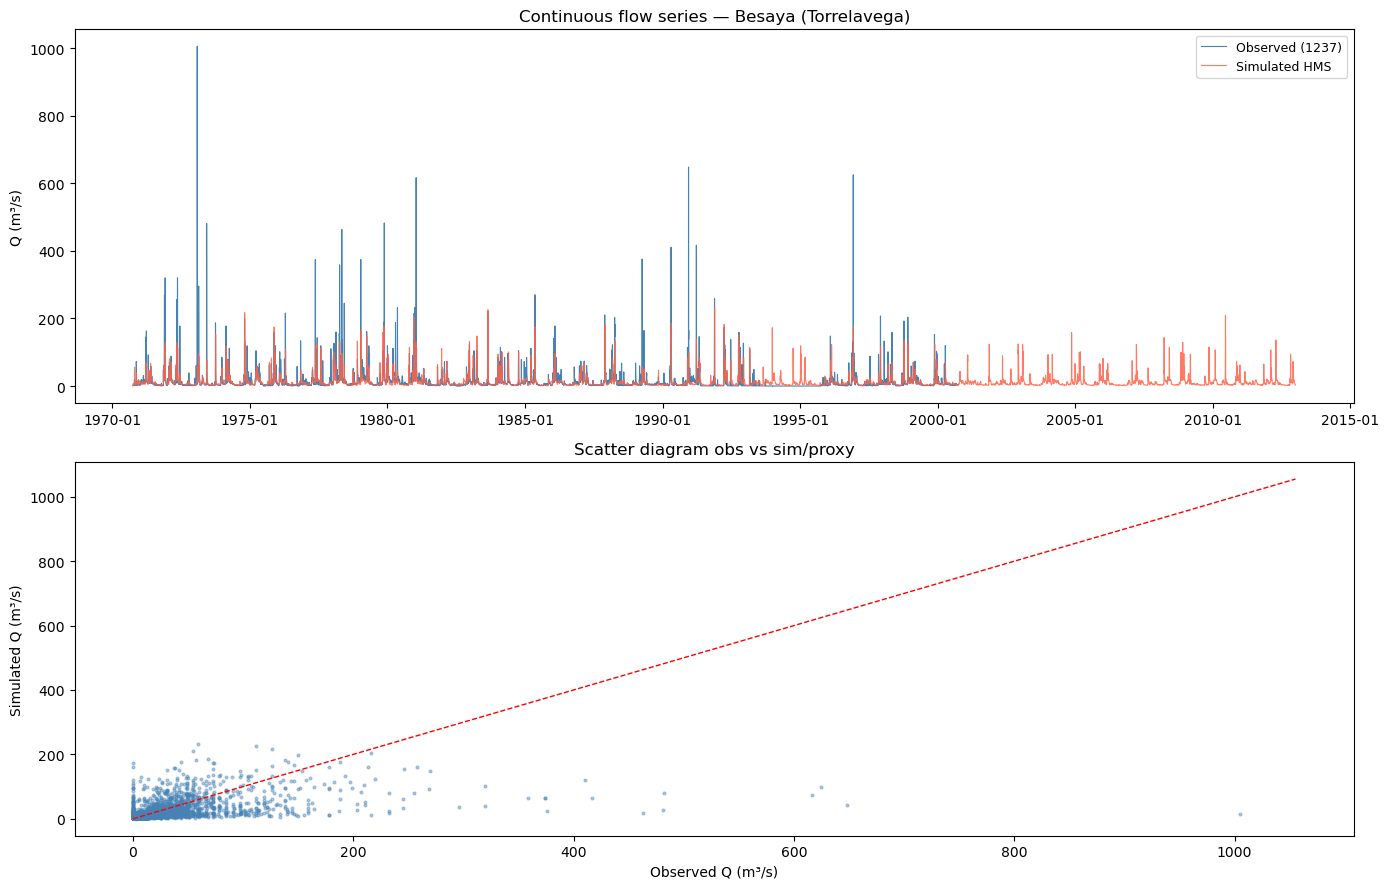

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(Q_obs.index, Q_obs.values, color='steelblue', lw=0.8, label='Observed (1237)')
if Q_sim is not None:
    ax.plot(Q_sim.index, Q_sim.values, color='tomato', lw=0.8, alpha=0.85, label='Simulated HMS')
ax.set(ylabel='Q (m³/s)', title='Continuous flow series — Besaya (Torrelavega)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Scatter obs vs sim
ax2 = axes[1]
if Q_sim is not None:
    common_idx = Q_obs.index.intersection(Q_sim.index)
    ax2.scatter(Q_obs.loc[common_idx], Q_sim.loc[common_idx],
                s=4, alpha=0.4, color='steelblue')
    lim = [0, max(Q_obs.max(), Q_sim.max()) * 1.05]
    ax2.plot(lim, lim, 'r--', lw=1)
    ax2.set(xlabel='Observed Q (m³/s)', ylabel='Simulated Q (m³/s)',
            title='Scatter diagram obs vs sim/proxy')
else:
    ax2.text(0.5, 0.5, 'Simulated data not available',
             ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig(OUT_DIR / 'simulation_diagnostics_plot.png', dpi=150)
plt.show()

---
## 5b. Analysis of Las Caldas Station (upstream validation)

Las Caldas gauge is located downstream of Los Corrales and integrates a larger portion of the Besaya basin. 
This section evaluates the continuous simulation at Las Caldas against observed streamflow for the historical period (1973-2000).

Las Caldas Station Diagnostic Comparison (daily):
Daily NSE  = 0.536
Daily KGE  = 0.644
Daily Bias = +7.4%

Las Caldas Station Diagnostic Comparison (resampled to monthly mean):
Monthly NSE  = 0.728
Monthly KGE  = 0.767
Monthly Bias = +7.1%


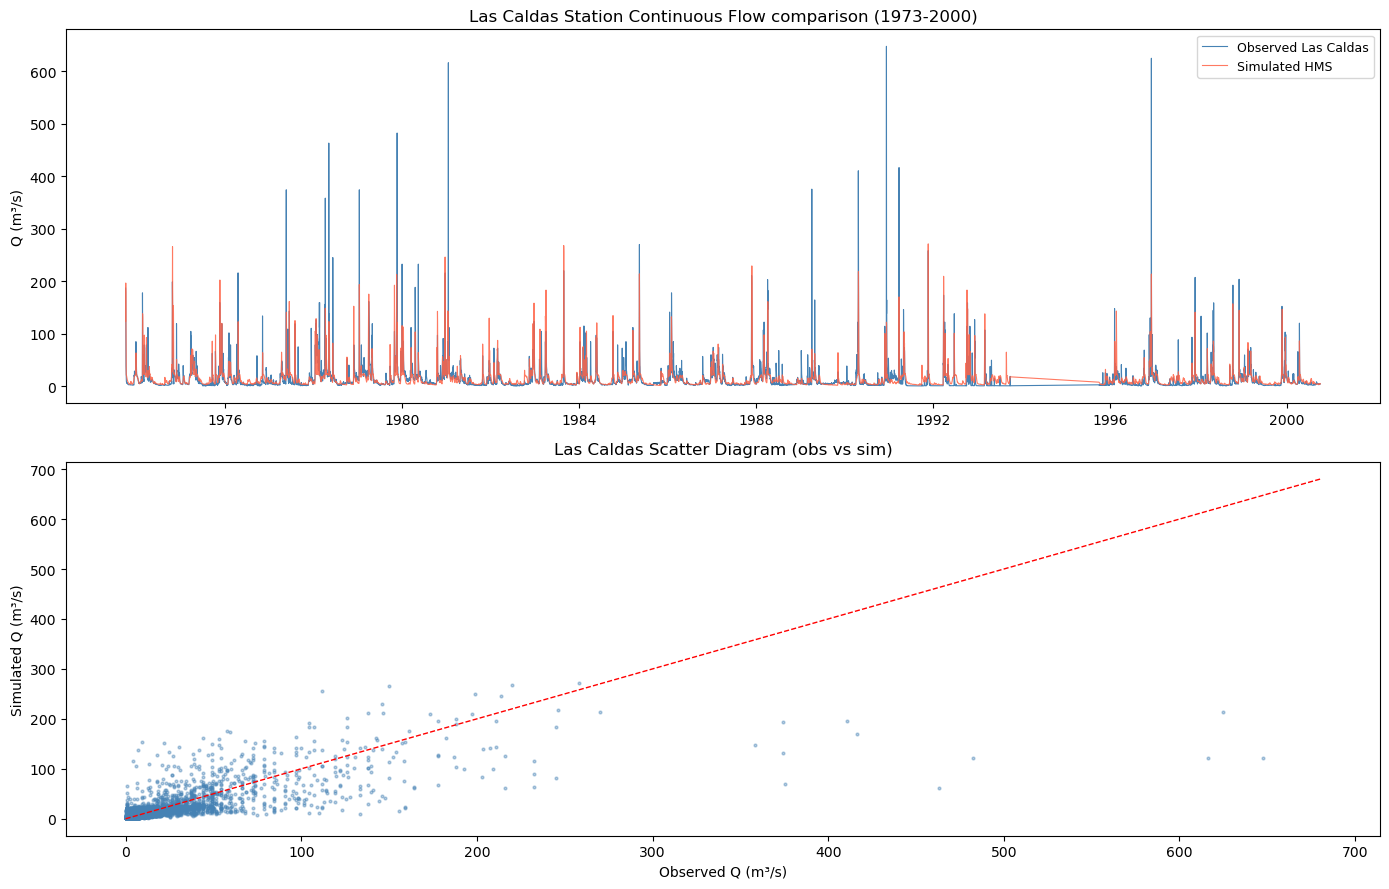

In [9]:
# ── Analysis of Las Caldas Station ──────────────────────────────────────────
_caldas_csv = PROC_DIR / 'Las_caldas.csv'
if _caldas_csv.exists():
    try:
        # Load and parse Las Caldas data
        _df_caldas = pd.read_csv(_caldas_csv, index_col=0)
        _df_caldas.index = pd.DatetimeIndex([_parse_mixed_date(x) for x in _df_caldas.index])
        
        # Drop NaNs for valid periods
        _df_caldas_valid = _df_caldas.dropna()
        _df_caldas_valid = _df_caldas_valid[_df_caldas_valid.index >= '1973-10-01']
        
        o_c = _df_caldas_valid['Real'].values.astype(float)
        s_c = _df_caldas_valid['Simulado'].values.astype(float)
        
        nse_c = nse(o_c, s_c)
        kge_c = kge(o_c, s_c)
        bias_c = bias_pct(o_c, s_c)
        
        # Monthly resampling
        _df_caldas_m = _df_caldas_valid.resample('M').mean().dropna()
        o_cm = _df_caldas_m['Real'].values.astype(float)
        s_cm = _df_caldas_m['Simulado'].values.astype(float)
        
        nse_cm = nse(o_cm, s_cm)
        kge_cm = kge(o_cm, s_cm)
        bias_cm = bias_pct(o_cm, s_cm)
        
        print('Las Caldas Station Diagnostic Comparison (daily):')
        print(f'Daily NSE  = {nse_c:.3f}')
        print(f'Daily KGE  = {kge_c:.3f}')
        print(f'Daily Bias = {bias_c:+.1f}%')
        
        print('\nLas Caldas Station Diagnostic Comparison (resampled to monthly mean):')
        print(f'Monthly NSE  = {nse_cm:.3f}')
        print(f'Monthly KGE  = {kge_cm:.3f}')
        print(f'Monthly Bias = {bias_cm:+.1f}%')
        
        # Plot comparison
        fig, axes = plt.subplots(2, 1, figsize=(14, 9))
        
        ax = axes[0]
        ax.plot(_df_caldas_valid.index, _df_caldas_valid['Real'], color='steelblue', lw=0.8, label='Observed Las Caldas')
        ax.plot(_df_caldas_valid.index, _df_caldas_valid['Simulado'], color='tomato', lw=0.8, alpha=0.85, label='Simulated HMS')
        ax.set(ylabel='Q (m³/s)', title='Las Caldas Station Continuous Flow comparison (1973-2000)')
        ax.legend(fontsize=9)
        
        # Scatter obs vs sim
        ax2 = axes[1]
        ax2.scatter(_df_caldas_valid['Real'], _df_caldas_valid['Simulado'], s=4, alpha=0.4, color='steelblue')
        lim = [0, max(_df_caldas_valid['Real'].max(), _df_caldas_valid['Simulado'].max()) * 1.05]
        ax2.plot(lim, lim, 'r--', lw=1)
        ax2.set(xlabel='Observed Q (m³/s)', ylabel='Simulated Q (m³/s)', title='Las Caldas Scatter Diagram (obs vs sim)')
        
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'las_caldas_diagnostics_plot.png', dpi=150)
        plt.show()
        
    except Exception as e:
        print(f'[WARN] Error processing Las Caldas: {e}')
else:
    print('Las_caldas.csv not found in the processed data directory')


---
## 6. Event extraction above threshold

**Threshold selection:**  
`threshold = Q75` (75th percentile of Q_obs) is used as the event-separation 
threshold. This corresponds to the minimum discharge that triggers a significant 
flood response in the Besaya. Lower thresholds produce too many small events that 
clutter the copula fit; higher thresholds leave too few events for calibration.

**Why extract events?**  
The hybrid downscaling method (Notebook 06) requires a set of 
**observed flood events** characterised by (Qmax, Qmed, Duration). These three 
variables are the inputs to the Gaussian copula and K-means classifier. 
Minimum requirements: ≥ 30 independent events for a reliable copula fit.

> **Independence check:** Two events are considered independent if their 
> separation exceeds 5 days AND both recede below the threshold between them.


In [10]:
# ── Load pre-calculated events from original data ──────────────────
EVENTOS_OBS  = DATA_ROOT / 'processed' / 'eventos_observados.csv'
EVENTOS_CLAS = DATA_ROOT / 'processed' / 'eventos_clasificados.csv'

if EVENTOS_OBS.exists():
    events_df = pd.read_csv(EVENTOS_OBS)
    print(f'Pre-calculated observed events: {len(events_df)}')
    print(events_df.describe().round(1))
else:
    # Calculate from flow series using pyhydra
    print(f'P90 threshold = {Q_threshold:.1f} m³/s')
    from pyhydra.climate.time_series.events import extract_discharge_events
    events_df = extract_discharge_events(Q_obs, threshold=Q_threshold, plot=False)
    events_df.to_csv(EVENTOS_OBS, index=False)
    print(f'Extracted and exported events: {len(events_df)}')

events_df.head()

Pre-calculated observed events: 262
       Inicio_evento  Fin_evento    Qmax   Qmed  Duracion  shape_type
count          262.0       262.0   262.0  262.0     262.0       262.0
mean          4869.8      4874.8   106.7   45.5       5.0         1.5
std           3170.9      3171.1   116.0   39.9       5.3         1.2
min             39.0        45.0    30.0    3.9       1.0         0.0
25%           2189.2      2190.5    41.5   26.9       2.0         0.0
50%           4445.0      4455.0    68.2   34.9       3.0         1.0
75%           7379.2      7383.0   119.0   54.7       6.0         3.0
max          10782.0     10784.0  1005.0  505.0      38.0         3.0


,Inicio_evento,Fin_evento,Qmax,Qmed,Duracion,shape_type
0,39,45,72.33,12.578571,6,0
1,138,139,30.90,28.070000,1,1
2,168,176,144.67,58.814444,8,2
3,175,178,163.00,100.662500,3,1
4,200,203,92.07,29.077500,3,0


In [11]:
# Extract rainfall episodes concurrent with flow events
pma_file = PROC_DIR / 'pma_idw_daily.csv'
if pma_file.exists() and isinstance(events_df, pd.DataFrame) and not events_df.empty:
    pma = pd.read_csv(pma_file, index_col=0, parse_dates=True).clip(lower=0)
    series_dict = {'Q_obs': Q_obs, 'PMA': pma.mean(axis=1)}

    col_start = 'start' if 'start' in events_df.columns else 'Inicio_evento'
    col_end   = 'end'   if 'end'   in events_df.columns else 'Fin_evento'

    if col_start in events_df.columns and col_end in events_df.columns:
        Q_idx = Q_obs.index
        bounds_rows = []
        for _, row in events_df.iterrows():
            try:
                i0, i1 = int(row[col_start]), int(row[col_end])
                if i0 < len(Q_idx) and i1 < len(Q_idx):
                    bounds_rows.append({'start': Q_idx[i0], 'end': Q_idx[i1]})
            except (ValueError, TypeError):
                try:
                    bounds_rows.append({'start': pd.to_datetime(row[col_start]),
                                        'end': pd.to_datetime(row[col_end])})
                except Exception:
                    pass

        event_bounds = pd.DataFrame(bounds_rows)
        if not event_bounds.empty:
            events_concurrent_df = extract_concurrent_events(event_bounds, series_dict, buffer_days=3)
            print(f'Episodes with both rainfall and flow data: {len(events_concurrent_df)}')
            events_concurrent_df.to_csv(OUT_DIR / 'eventos_caudal_lluvia.csv', index=False)
            print(events_concurrent_df.head())
        else:
            print('No convertible event indices — check format of eventos_observados.csv')
    else:
        print(f'Start/end columns not found. Available columns: {list(events_df.columns)}')
else:
    print('PMA not available or no events — skipping concurrent extraction')


Episodes with both rainfall and flow data: 262
  event_start  event_end  Q_obs_max  Q_obs_mean  Q_obs_total    PMA_max  \
0  1970-11-09 1970-11-15      72.33   11.890000       154.57  26.124404   
1  1971-02-17 1971-02-18      30.90   20.490000       163.92  18.670724   
2  1971-03-19 1971-03-27     163.00   54.728667       820.93  29.635509   
3  1971-03-26 1971-03-29     163.00   58.853000       588.53  11.067871   
4  1971-04-20 1971-04-23      92.07   19.050000       190.50  28.294024   

   PMA_mean   PMA_total  
0  7.899805  102.697460  
1  6.834417   54.675338  
2  8.406755  126.101332  
3  3.062107   30.621070  
4  7.384099   73.840995  


---
## 7. Event statistics — preparation for downscaling

The flow duration curve (FDC) provides the empirical exceedance probability 
at each discharge level — used to:
1. Estimate the return period of each observed event (plotting position)
2. Cross-check the Q75 threshold against the 25% exceedance probability
3. Compute Q90 (ecological flow) and Q10 (flood-prone flow)

**Exported outputs:**
| File | Content | Used in |
|------|---------|---------|
| `eventos_observados.csv` | Event table (Qmax, Qmed, Duration, start date) | NB06 copula |
| `pma_idw_daily.csv` | Already from NB02 | NB06 concurrent precipitation |


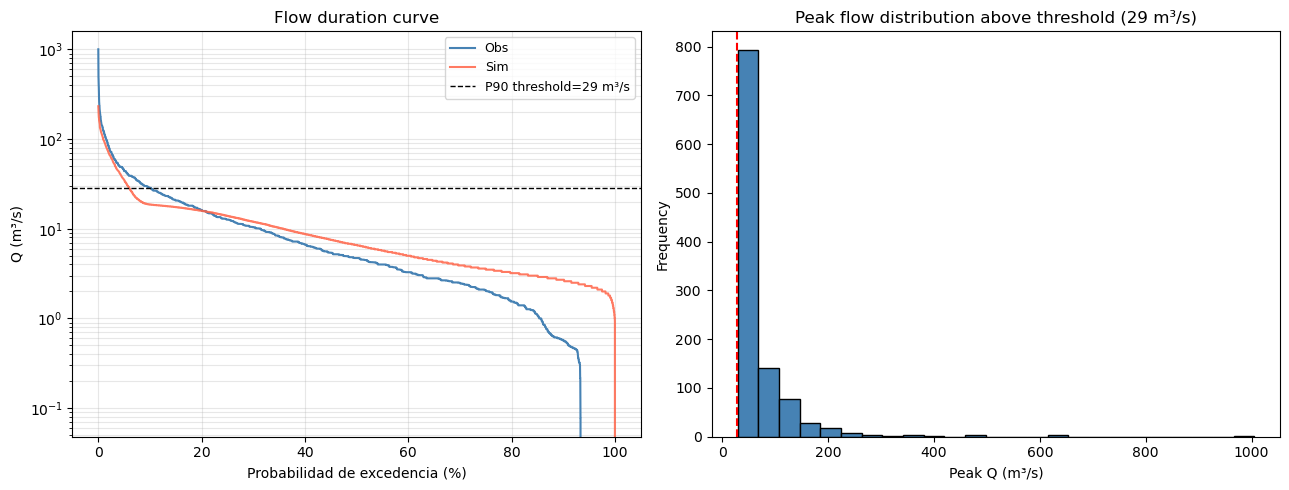

In [12]:
# Compute flow duration curve (FDC)
q_sorted = np.sort(Q_obs.dropna().values)[::-1]
exceedance = np.linspace(0, 100, len(q_sorted))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(exceedance, q_sorted, color='steelblue', lw=1.5, label='Obs')
if Q_sim is not None:
    q_sim_sorted = np.sort(Q_sim.reindex(Q_obs.index).dropna().values)[::-1]
    exc_sim = np.linspace(0, 100, len(q_sim_sorted))
    ax.semilogy(exc_sim, q_sim_sorted, color='tomato', lw=1.5, alpha=0.85, label='Sim')
ax.axhline(Q_threshold, color='k', ls='--', lw=1, label=f'P90 threshold={Q_threshold:.0f} m³/s')
ax.set(xlabel='Probabilidad de excedencia (%)', ylabel='Q (m³/s)',
       title='Flow duration curve')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Histogram of flows above threshold
ax = axes[1]
q_above = Q_obs[Q_obs > Q_threshold].values
if len(q_above) > 0:
    ax.hist(q_above, bins=25, color='steelblue', edgecolor='k')
ax.axvline(Q_threshold, color='r', lw=1.5, ls='--')
ax.set(xlabel='Peak Q (m³/s)', ylabel='Frequency',
       title=f'Peak flow distribution above threshold ({Q_threshold:.0f} m³/s)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fdc_eventos.png', dpi=150)
plt.show()